# k_max = 256

In [59]:
import numpy as np
import torch

from lib.velocity_field import *
from lib.shared_memory_utils import *
from lib.zermelo_env import *
from lib.algs_parallel import *

mp.set_start_method("spawn", force=True)

VelField = TurbFlow("/storage/p2/parfenyev/RL/opt-navig/Data Generation/2d-turb-data.jld", steady=False)

CFG = TURB_TIME_P1.copy()

CFG_05 = TURB_TIME_P1.copy()
CFG_05["Va"] = 3.8185675 / 2

CFG_066 = TURB_TIME_P1.copy()
CFG_066["Va"] = 3.8185675 * 2 / 3

CFG_15 = TURB_TIME_P1.copy()
CFG_15["Va"] = 3.8185675 * 3 / 2


env = ZermeloEnv(CFG, VelField)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]

best_policy = PolicyNet(obs_dim, act_dim)
best_policy.load_state_dict(torch.load("./saved_models/coarse-grained/tp1.pth"))

best_policy_05 = PolicyNet(obs_dim, act_dim)
best_policy_05.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-05.pth"))

best_policy_066 = PolicyNet(obs_dim, act_dim)
best_policy_066.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-066.pth"))

best_policy_15 = PolicyNet(obs_dim, act_dim)
best_policy_15.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-15.pth"))

<All keys matched successfully>

### Model Evaluation

In [66]:
import h5py

env = ZermeloEnv(CFG, VelField)
results = evaluate_policy(model=best_policy, env=env, n_eval=50)

env_05 = ZermeloEnv(CFG_05, VelField)
results_05 = evaluate_policy(model=best_policy_05, env=env_05, n_eval=50)

env_066 = ZermeloEnv(CFG_066, VelField)
results_066 = evaluate_policy(model=best_policy_066, env=env_066, n_eval=50)

env_15 = ZermeloEnv(CFG_15, VelField)
results_15 = evaluate_policy(model=best_policy_15, env=env_15, n_eval=50)

trajectories = [r["trajectory"] for r in results]
trajectories_05 = [r["trajectory"] for r in results_05]
trajectories_066 = [r["trajectory"] for r in results_066]
trajectories_15 = [r["trajectory"] for r in results_15]

times = [r["time"] for r in results]
times_05 = [r["time"] for r in results_05]
times_066 = [r["time"] for r in results_066]
times_15 = [r["time"] for r in results_15]

### Figure 8a

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_figure_8a(env, trajectories_A, time_A, n_vort=200, n_vel=36, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6, 6))

       
    # Vorticity field
    x = np.linspace(env.x_min, env.x_max, n_vort)
    y = np.linspace(env.y_min, env.y_max, n_vort)
    X, Y = np.meshgrid(x, y)

    VORT = np.vectorize(env.vel_field.vort)(X, Y, time_A)
    vmax = np.max(np.abs(VORT))

    im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1, rasterized=True)

    # Velocity field
    xq = np.linspace(env.x_min, env.x_max, n_vel)
    yq = np.linspace(env.y_min, env.y_max, n_vel)
    Xq, Yq = np.meshgrid(xq, yq)

    U = np.vectorize(env.vel_field.velX)(Xq, Yq, time_A)
    V = np.vectorize(env.vel_field.velY)(Xq, Yq, time_A)

    ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

    # Trajectories
    colors = ["magenta"] * 10 + ["red"] * 10 + ["blue"] * 10 + ["yellow"] * 10

    for traj, color in zip(trajectories_A, colors):
        ax.plot(traj[:, 0], traj[:, 1], lw=1, color=color, zorder=3)

    # Legend
    legend_elements = [
        Line2D([0], [0], color="magenta", lw=2, label=r"$V_0 \approx 5.7$"),
        Line2D([0], [0], color="red",     lw=2, label=r"$V_0 \approx 3.8$"),
        Line2D([0], [0], color="blue",    lw=2, label=r"$V_0 \approx 2.5$"),
        Line2D([0], [0], color="yellow",  lw=2, label=r"$V_0 \approx 1.9$"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=16,
        frameon=True
    )

    ax.add_patch(plt.Circle((env.xA, env.yA), env.rA, color="tomato", alpha=1, zorder=4))
    ax.add_patch(plt.Circle((env.xB, env.yB), env.rB, color="tomato", alpha=1, zorder=4))

    ax.text(env.xA, env.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
    ax.text(env.xB, env.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

    time_text = ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=20, color="white", zorder=10)
    time_text.set_text(f"t = {time_A:.3f} s")

    # Formatting
    ax.set_title(r"$k_{max}=256$", fontsize=24)
    ax.set_xlim(env.x_min, env.x_max)
    ax.set_ylim(env.y_min, env.y_max)
    ax.set_aspect("equal")

    ax.set_xlabel("x", fontsize=32)
    ax.set_ylabel("y", fontsize=32)

    ax.set_xticks([0, 2, 4, 6])
    ax.set_yticks([0, 2, 4, 6])
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(False)
    
    plt.savefig("./figures/fig8a.svg", format="svg", bbox_inches="tight", dpi=300, pad_inches=0)

    plt.show()
    plt.close(fig)

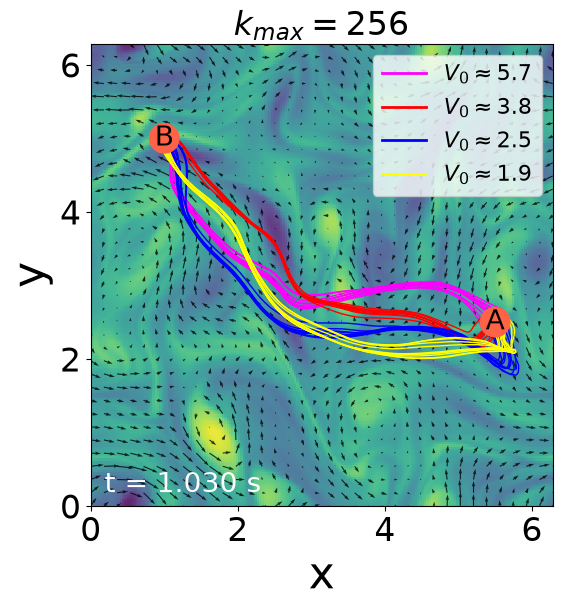

In [67]:
plot_figure_8a(env, trajectories_15[0:10] + trajectories[0:10] + trajectories_066[0:10] + trajectories_05[0:10],
              time_A = max(max(times[0:10]), max(times_05[0:10]), max(times_066[0:10]), max(times_15[0:10])))

# k_max = 5

In [55]:
import numpy as np
import torch

from lib.velocity_field import *
from lib.shared_memory_utils import *
from lib.zermelo_env import *
from lib.algs_parallel import *

mp.set_start_method("spawn", force=True)

VelField = TurbFlow("/storage/p2/parfenyev/RL/opt-navig/Data Generation/2d-turb-data.jld", steady=False)
VelFieldFilt = TurbFlow("/storage/p2/parfenyev/RL/opt-navig/Data Generation/2d-turb-data-filter-k5.jld", steady=False)

CFG = TURB_TIME_P1.copy()

CFG_05 = TURB_TIME_P1.copy()
CFG_05["Va"] = 3.8185675 / 2

CFG_066 = TURB_TIME_P1.copy()
CFG_066["Va"] = 3.8185675 * 2 / 3

CFG_15 = TURB_TIME_P1.copy()
CFG_15["Va"] = 3.8185675 * 3 / 2


env = ZermeloEnv(CFG, VelField)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]

best_policy = PolicyNet(obs_dim, act_dim)
best_policy.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-k5.pth"))

best_policy_05 = PolicyNet(obs_dim, act_dim)
best_policy_05.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-05-k5.pth"))

best_policy_066 = PolicyNet(obs_dim, act_dim)
best_policy_066.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-066-k5.pth"))

best_policy_15 = PolicyNet(obs_dim, act_dim)
best_policy_15.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-15-k5.pth"))

<All keys matched successfully>

In [56]:
env = ZermeloEnv(CFG, VelField)
results = evaluate_policy(model=best_policy, env=env, n_eval=50)

env_05 = ZermeloEnv(CFG_05, VelField)
results_05 = evaluate_policy(model=best_policy_05, env=env_05, n_eval=50)

env_066 = ZermeloEnv(CFG_066, VelField)
results_066 = evaluate_policy(model=best_policy_066, env=env_066, n_eval=50)

env_15 = ZermeloEnv(CFG_15, VelField)
results_15 = evaluate_policy(model=best_policy_15, env=env_15, n_eval=50)

trajectories = [r["trajectory"] for r in results]
trajectories_05 = [r["trajectory"] for r in results_05]
trajectories_066 = [r["trajectory"] for r in results_066]
trajectories_15 = [r["trajectory"] for r in results_15]

times = [r["time"] for r in results]
times_05 = [r["time"] for r in results_05]
times_066 = [r["time"] for r in results_066]
times_15 = [r["time"] for r in results_15]

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_figure_8b(env, trajectories_A, time_A, n_vort=200, n_vel=36, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6, 6))

       
    # Vorticity field
    x = np.linspace(env.x_min, env.x_max, n_vort)
    y = np.linspace(env.y_min, env.y_max, n_vort)
    X, Y = np.meshgrid(x, y)

    VORT = np.vectorize(env.vel_field.vort)(X, Y, time_A)
    vmax = np.max(np.abs(VORT))

    im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1, rasterized=True)

    # Velocity field
    xq = np.linspace(env.x_min, env.x_max, n_vel)
    yq = np.linspace(env.y_min, env.y_max, n_vel)
    Xq, Yq = np.meshgrid(xq, yq)

    U = np.vectorize(env.vel_field.velX)(Xq, Yq, time_A)
    V = np.vectorize(env.vel_field.velY)(Xq, Yq, time_A)

    ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

    # Trajectories
    colors = ["magenta"] * 10 + ["red"] * 10 + ["blue"] * 10 + ["yellow"] * 10

    for traj, color in zip(trajectories_A, colors):
        ax.plot(traj[:, 0], traj[:, 1], lw=1, color=color, zorder=3)

    """
    # Legend
    legend_elements = [
        Line2D([0], [0], color="magenta", lw=2, label=r"$V_0 \approx 5.7$"),
        Line2D([0], [0], color="red",     lw=2, label=r"$V_0 \approx 3.8$"),
        Line2D([0], [0], color="blue",    lw=2, label=r"$V_0 \approx 2.5$"),
        Line2D([0], [0], color="yellow",  lw=2, label=r"$V_0 \approx 1.9$"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=16,
        frameon=True
    )
    """

    ax.add_patch(plt.Circle((env.xA, env.yA), env.rA, color="tomato", alpha=1, zorder=4))
    ax.add_patch(plt.Circle((env.xB, env.yB), env.rB, color="tomato", alpha=1, zorder=4))

    ax.text(env.xA, env.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
    ax.text(env.xB, env.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

    time_text = ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=20, color="white", zorder=10)
    time_text.set_text(f"t = {time_A:.3f} s")

    # Formatting
    ax.set_title(r"$k_{max}=5$", fontsize=24)
    ax.set_xlim(env.x_min, env.x_max)
    ax.set_ylim(env.y_min, env.y_max)
    ax.set_aspect("equal")

    ax.set_xlabel("x", fontsize=32)
    ax.set_ylabel("y", fontsize=32)

    ax.set_xticks([0, 2, 4, 6])
    ax.set_yticks([0, 2, 4, 6])
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(False)
    
    plt.savefig("./figures/fig8b.svg", format="svg", bbox_inches="tight", dpi=300, pad_inches=0)

    plt.show()
    plt.close(fig)

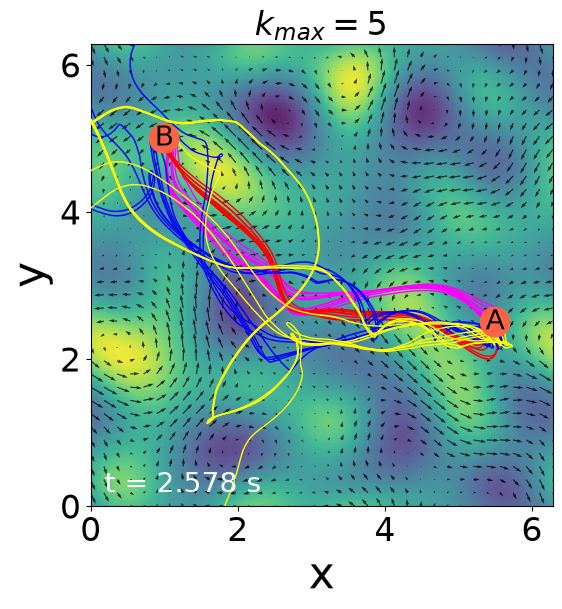

In [58]:
env = ZermeloEnv(CFG, VelFieldFilt)

plot_figure_8b(env, trajectories_15[0:10] + trajectories[0:10] + trajectories_066[0:10] + trajectories_05[0:10],
              time_A = max(max(times[0:10]), max(times_05[0:10]), max(times_066[0:10]), max(times_15[0:10])))

# k_max = 2

In [40]:
import numpy as np
import torch

from lib.velocity_field import *
from lib.shared_memory_utils import *
from lib.zermelo_env import *
from lib.algs_parallel import *

mp.set_start_method("spawn", force=True)

VelField = TurbFlow("/storage/p2/parfenyev/RL/opt-navig/Data Generation/2d-turb-data.jld", steady=False)
VelFieldFilt = TurbFlow("/storage/p2/parfenyev/RL/opt-navig/Data Generation/2d-turb-data-filter-k2.jld", steady=False)

CFG = TURB_TIME_P1.copy()

CFG_05 = TURB_TIME_P1.copy()
CFG_05["Va"] = 3.8185675 / 2

CFG_066 = TURB_TIME_P1.copy()
CFG_066["Va"] = 3.8185675 * 2 / 3

CFG_15 = TURB_TIME_P1.copy()
CFG_15["Va"] = 3.8185675 * 3 / 2


env = ZermeloEnv(CFG, VelField)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]

best_policy = PolicyNet(obs_dim, act_dim)
best_policy.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-k2.pth"))

best_policy_05 = PolicyNet(obs_dim, act_dim)
best_policy_05.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-05-k2.pth"))

best_policy_066 = PolicyNet(obs_dim, act_dim)
best_policy_066.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-066-k2.pth"))

best_policy_15 = PolicyNet(obs_dim, act_dim)
best_policy_15.load_state_dict(torch.load("./saved_models/coarse-grained/tp1-15-k2.pth"))

<All keys matched successfully>

In [50]:
env = ZermeloEnv(CFG, VelField)
results = evaluate_policy(model=best_policy, env=env, n_eval=50)

env_05 = ZermeloEnv(CFG_05, VelField)
results_05 = evaluate_policy(model=best_policy_05, env=env_05, n_eval=50)

env_066 = ZermeloEnv(CFG_066, VelField)
results_066 = evaluate_policy(model=best_policy_066, env=env_066, n_eval=50)

env_15 = ZermeloEnv(CFG_15, VelField)
results_15 = evaluate_policy(model=best_policy_15, env=env_15, n_eval=50)

trajectories = [r["trajectory"] for r in results]
trajectories_05 = [r["trajectory"] for r in results_05]
trajectories_066 = [r["trajectory"] for r in results_066]
trajectories_15 = [r["trajectory"] for r in results_15]

times = [r["time"] for r in results]
times_05 = [r["time"] for r in results_05]
times_066 = [r["time"] for r in results_066]
times_15 = [r["time"] for r in results_15]

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_figure_8c(env, trajectories_A, time_A, n_vort=200, n_vel=36, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6, 6))

       
    # Vorticity field
    x = np.linspace(env.x_min, env.x_max, n_vort)
    y = np.linspace(env.y_min, env.y_max, n_vort)
    X, Y = np.meshgrid(x, y)

    VORT = np.vectorize(env.vel_field.vort)(X, Y, time_A)
    vmax = np.max(np.abs(VORT))

    im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1, rasterized=True)

    # Velocity field
    xq = np.linspace(env.x_min, env.x_max, n_vel)
    yq = np.linspace(env.y_min, env.y_max, n_vel)
    Xq, Yq = np.meshgrid(xq, yq)

    U = np.vectorize(env.vel_field.velX)(Xq, Yq, time_A)
    V = np.vectorize(env.vel_field.velY)(Xq, Yq, time_A)

    ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

    # Trajectories
    colors = ["magenta"] * 10 + ["red"] * 10 + ["blue"] * 10 + ["yellow"] * 10

    for traj, color in zip(trajectories_A, colors):
        ax.plot(traj[:, 0], traj[:, 1], lw=1, color=color, zorder=3)

    """
    # Legend
    legend_elements = [
        Line2D([0], [0], color="magenta", lw=2, label=r"$V_0 \approx 5.7$"),
        Line2D([0], [0], color="red",     lw=2, label=r"$V_0 \approx 3.8$"),
        Line2D([0], [0], color="blue",    lw=2, label=r"$V_0 \approx 2.5$"),
        Line2D([0], [0], color="yellow",  lw=2, label=r"$V_0 \approx 1.9$"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=16,
        frameon=True
    )
    """

    ax.add_patch(plt.Circle((env.xA, env.yA), env.rA, color="tomato", alpha=1, zorder=4))
    ax.add_patch(plt.Circle((env.xB, env.yB), env.rB, color="tomato", alpha=1, zorder=4))

    ax.text(env.xA, env.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
    ax.text(env.xB, env.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

    time_text = ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=20, color="white", zorder=10)
    time_text.set_text(f"t = {time_A:.3f} s")

    # Formatting
    ax.set_title(r"$k_{max}=2$", fontsize=24)
    ax.set_xlim(env.x_min, env.x_max)
    ax.set_ylim(env.y_min, env.y_max)
    ax.set_aspect("equal")

    ax.set_xlabel("x", fontsize=32)
    ax.set_ylabel("y", fontsize=32)

    ax.set_xticks([0, 2, 4, 6])
    ax.set_yticks([0, 2, 4, 6])
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(False)
    
    plt.savefig("./figures/fig8c.svg", format="svg", bbox_inches="tight", dpi=300, pad_inches=0)

    plt.show()
    plt.close(fig)

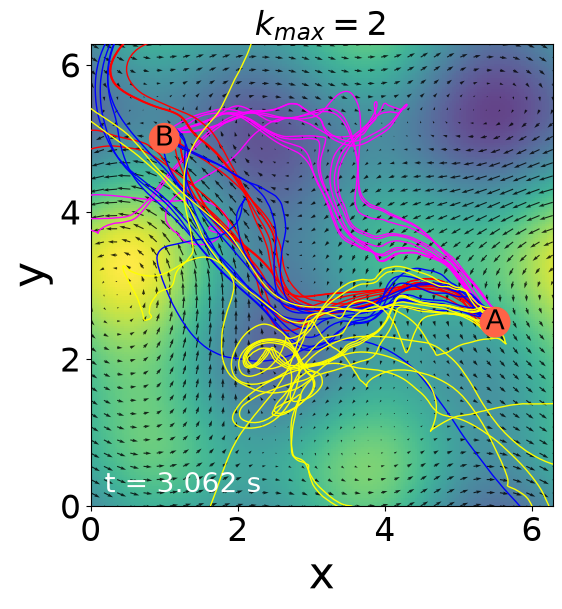

In [54]:
env = ZermeloEnv(CFG, VelFieldFilt)

plot_figure_8c(env, trajectories_15[0:10] + trajectories[0:10] + trajectories_066[0:10] + trajectories_05[0:10],
              time_A = max(max(times[0:10]), max(times_05[0:10]), max(times_066[0:10]), max(times_15[0:10])))